In [1]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Path to your raw data folder
data_path = "../data/raw/" 
all_files = glob.glob(os.path.join(data_path, "*.csv"))

print(f"Found {len(all_files)} CSV files. Starting data ingestion...\n")

# Load and append all CSVs
df_list = []
for file in all_files:
    filename = os.path.basename(file)
    print(f"Loading: {filename}...")
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Concatenate all dataframes into one massive dataset
print("\nConcatenating datasets... (Watch your RAM!)")
df_honest = pd.concat(df_list, axis=0, ignore_index=True)
print(f"Total dataset shape: {df_honest.shape}")

# 2. Honest Analysis: Drop leakage features strictly
leakage_features = ['Dst Port', 'Protocol', 'Timestamp']
cols_to_drop = [col for col in leakage_features if col in df_honest.columns]
df_honest = df_honest.drop(columns=cols_to_drop)

# 3. Handle infinite and null values
print("Cleaning Data (NaNs and Infs)...")
df_honest = df_honest.replace([np.inf, -np.inf], np.nan).dropna()

# 4. Multiclass Label Encoding
print("\nTarget Distribution (Multiclass):")
print(df_honest['Label'].value_counts())

X = df_honest.drop('Label', axis=1)
y_raw = df_honest['Label']

# Convert text labels to integers (0, 1, 2, 3...)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Save and print the mapping to understand the new classes
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel Encoding Mapping:")
for name, code in label_mapping.items():
    print(f"Class {code}: {name}")

Found 2 CSV files. Starting data ingestion...

Loading: 02-14-2018.csv...
Loading: 02-15-2018.csv...

Concatenating datasets... (Watch your RAM!)
Total dataset shape: (2097150, 80)
Cleaning Data (NaNs and Infs)...

Target Distribution (Multiclass):
Label
Benign                   1651858
FTP-BruteForce            193354
SSH-Bruteforce            187589
DoS attacks-GoldenEye      41508
DoS attacks-Slowloris      10990
Name: count, dtype: int64

Label Encoding Mapping:
Class 0: Benign
Class 1: DoS attacks-GoldenEye
Class 2: DoS attacks-Slowloris
Class 3: FTP-BruteForce
Class 4: SSH-Bruteforce


--- 5-Fold Cross-Validation Multiclass Benchmark ---
Evaluating models... this will take a few minutes.

Decision Tree   | Mean Accuracy: 0.99986 (+/- 0.00002)
Random Forest   | Mean Accuracy: 0.99992 (+/- 0.00001)
XGBoost         | Mean Accuracy: 0.99993 (+/- 0.00002)


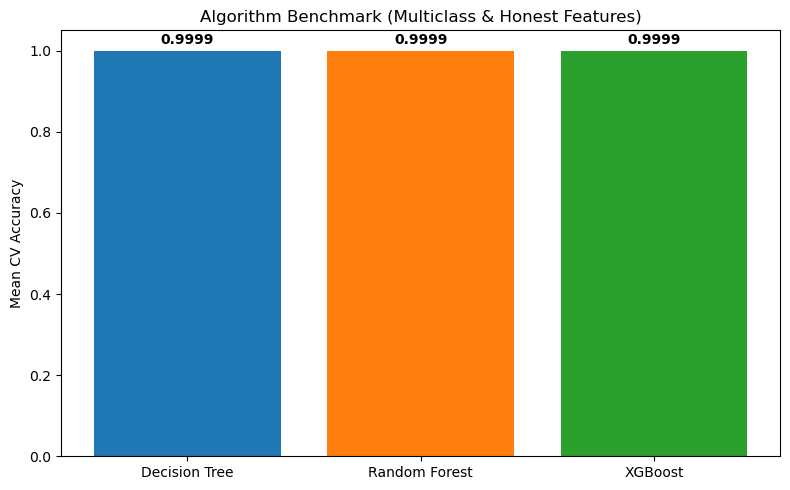

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Setup 5-Fold Cross Validation
# Stratified ensures class proportions are kept across all 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the models to benchmark
models = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=15, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)),
    ('XGBoost', xgb.XGBClassifier(eval_metric='mlogloss', n_jobs=-1, random_state=42))
]

# 3. Execute Robust Benchmark
print("--- 5-Fold Cross-Validation Multiclass Benchmark ---")
print("Evaluating models... this will take a few minutes.\n")

results = []
for name, model in models:
    # Run CV (returns an array of 5 accuracy scores)
    cv_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    results.append((name, mean_acc, std_acc))
    
    print(f"{name:15s} | Mean Accuracy: {mean_acc:.5f} (+/- {std_acc:.5f})")

# 4. Visualize the Benchmark
names = [r[0] for r in results]
means = [r[1] for r in results]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, means, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.0, 1.05)
plt.ylabel('Mean CV Accuracy')
plt.title('Algorithm Benchmark (Multiclass & Honest Features)')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Ojos vendados: Eliminadas 4 columnas de firmas mecánicas del script.

Aplicando Undersampling: Obligando a la IA a estudiar todas las clases por igual...

Distribución de filas para entrenar ANTES de balancear:
[1321486   33207    8792  154683  150071]
Distribución de filas para entrenar DESPUÉS de balancear:
[8792 8792 8792 8792 8792]

Entrenando XGBoost 'Súper Honesto'... (Tardará menos porque hay menos filas tras el balanceo)

--- Reporte de Clasificación (Súper Honesto + Balanceado) ---
                       precision    recall  f1-score   support

               Benign       1.00      1.00      1.00    330372
DoS attacks-GoldenEye       1.00      1.00      1.00      8301
DoS attacks-Slowloris       0.80      1.00      0.89      2198
       FTP-BruteForce       1.00      1.00      1.00     38671
       SSH-Bruteforce       1.00      1.00      1.00     37518

             accuracy                           1.00    417060
            macro avg       0.96      1.00      0.98    41706

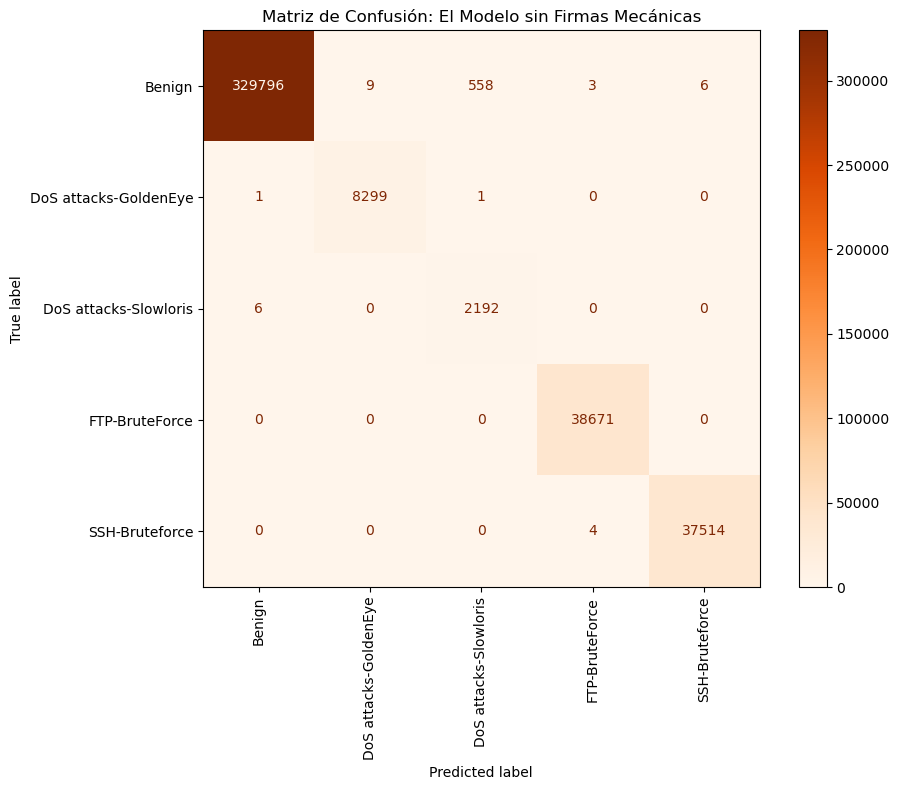

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler

# 1. Eliminar Firmas Mecánicas (Súper Honesto)
# El dataset original de CIC-IDS-2018 guarda estas huellas mecánicas en estas columnas:
script_signatures = [
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', # Tamaño inicial ventana TCP
    'Fwd Seg Size Min', 'Fwd Packet Length Min', 'Bwd Packet Length Min', 'Min Packet Length', # Tamaños mecánicos estáticos
    'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Min' # Tiempos mecánicos entre paquetes
]

cols_to_drop_super = [col for col in script_signatures if col in X.columns]
X_super_honest = X.drop(columns=cols_to_drop_super)

print(f"Ojos vendados: Eliminadas {len(cols_to_drop_super)} columnas de firmas mecánicas del script.\n")

# 2. Train-Test Split (El test siempre debe ser desbalanceado, como el mundo real)
X_train, X_test, y_train, y_test = train_test_split(X_super_honest, y, test_size=0.2, random_state=42, stratify=y)

# 3. Evaluación Honesta: Corregir Desbalanceo en el Entrenamiento
print("Aplicando Undersampling: Obligando a la IA a estudiar todas las clases por igual...")
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

# Mostrar cómo ha cambiado la distribución
print("\nDistribución de filas para entrenar ANTES de balancear:")
print(np.bincount(y_train))
print("Distribución de filas para entrenar DESPUÉS de balancear:")
print(np.bincount(y_train_bal))

# 4. Entrenar XGBoost sin trampas
print("\nEntrenando XGBoost 'Súper Honesto'... (Tardará menos porque hay menos filas tras el balanceo)")
clf = xgb.XGBClassifier(eval_metric='mlogloss', n_jobs=-1, random_state=42)
clf.fit(X_train_bal, y_train_bal)

# 5. Predicción en el mundo real (X_test)
y_pred = clf.predict(X_test)

# 6. Resultados y Matriz de Confusión
print("\n--- Reporte de Clasificación (Súper Honesto + Balanceado) ---")
target_names = le.inverse_transform(sorted(list(set(y))))
print(classification_report(y_test, y_pred, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=target_names, 
                                        cmap='Oranges', # Cambio a naranja para diferenciarlo del anterior
                                        ax=ax, 
                                        xticks_rotation='vertical')
plt.title("Matriz de Confusión: El Modelo sin Firmas Mecánicas")
plt.tight_layout()
plt.show()